# Projet : HR_Performance_Insights
## Objectif : Explorer et comprendre les performances des employés, analyser les distributions des scores et heures travaillées et détecter les outliers.


### Importation des bibliothèques nécessaires

In [1]:
# Bibliothèques à importer

import pandas as pd           # Pour la manipulation des données
import numpy as np            # Pour les calculs numériques
import matplotlib.pyplot as plt  # Pour les graphiques
import seaborn as sns             # Pour des visualisations plus esthétiques

# Configurer Seaborn
sns.set(style="darkgrid")

print("Bibliothèques importées et configuration faite")

Bibliothèques importées et configuration faite


### Chargement du dataset et vérification des données

In [2]:
#Ecrire le chemin d'accès du fichier correctement
df = pd.read_csv(r"C:\Users\Princia\Desktop\PROJETS\PROJETS POUR DEVENIR DATA ANALYST\Projet 2\HR_Dataset.csv")

print("Dataset chargé")

Dataset chargé


In [4]:
# Vérification rapide des données

df.info()
df.describe()
print(df.head())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

### Statistiques descriptives

In [5]:
# Statistiques descriptives
print("=== Statistiques de PerformanceScore ===")
print(df['PerformanceScore'].describe())

print(df['PerformanceScore'].unique())
print(df['PerformanceScore'].value_counts())


=== Statistiques de PerformanceScore ===
count             311
unique              4
top       Fully Meets
freq              243
Name: PerformanceScore, dtype: object
['Exceeds' 'Fully Meets' 'Needs Improvement' 'PIP']
PerformanceScore
Fully Meets          243
Exceeds               37
Needs Improvement     18
PIP                   13
Name: count, dtype: int64


In [6]:
## Création du mapping pour perfomance
perfomance_map = { 'Exceeds' : 4,
                   'Fully Meets' : 3,
                   'Needs Improvement': 2,
                   'PIP' : 1 }

In [7]:
## 2️⃣ Création d'une nouvelle colonne numérique
df['Perform_Score'] = df['PerformanceScore'].map(perfomance_map)

# Vérification rapide des colonnes
print(df['Perform_Score'].value_counts(dropna=False))
print(df['Perform_Score'].describe())

Perform_Score
3    243
4     37
2     18
1     13
Name: count, dtype: int64
count    311.000000
mean       2.977492
std        0.587072
min        1.000000
25%        3.000000
50%        3.000000
75%        3.000000
max        4.000000
Name: Perform_Score, dtype: float64


In [8]:
## Statistiques descriptives sur Perform_Score et autres colonnes utiles
cols_analyse = ['Perform_Score', 'Salary', 'Absences', 'DaysLateLast30']

for col in cols_analyse:
    if col in df.columns:
        print(f"\n=== Statistiques pour {col} ===")
        print(f"Moyenne : {df[col].mean()}")
        print(f"Médiane : {df[col].median()}")
        print(f"Mode : {df[col].mode()[0]}")
        print(f"Variance : {df[col].var()}")
        print(f"Écart-type : {df[col].std()}")


=== Statistiques pour Perform_Score ===
Moyenne : 2.977491961414791
Médiane : 3.0
Mode : 3
Variance : 0.3446530442900126
Écart-type : 0.5870715836165233

=== Statistiques pour Salary ===
Moyenne : 69020.6848874598
Médiane : 62810.0
Mode : 57815
Variance : 632856381.6100614
Écart-type : 25156.636929646647

=== Statistiques pour Absences ===
Moyenne : 10.237942122186496
Médiane : 10.0
Mode : 4
Variance : 34.252878332123174
Écart-type : 5.8525958627025645

=== Statistiques pour DaysLateLast30 ===
Moyenne : 0.41479099678456594
Médiane : 0.0
Mode : 0
Variance : 1.6757805206928689
Écart-type : 1.2945194168852272


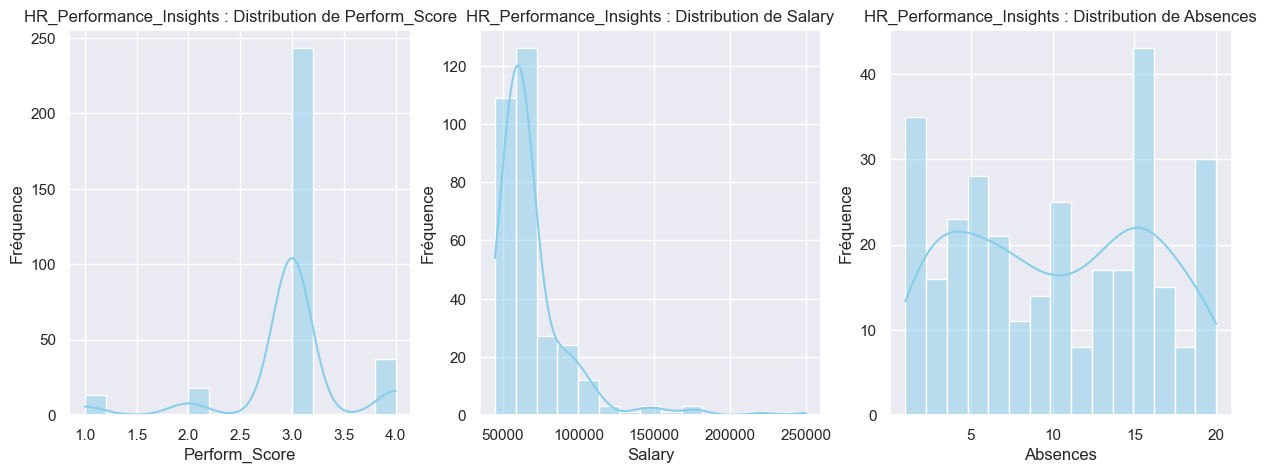

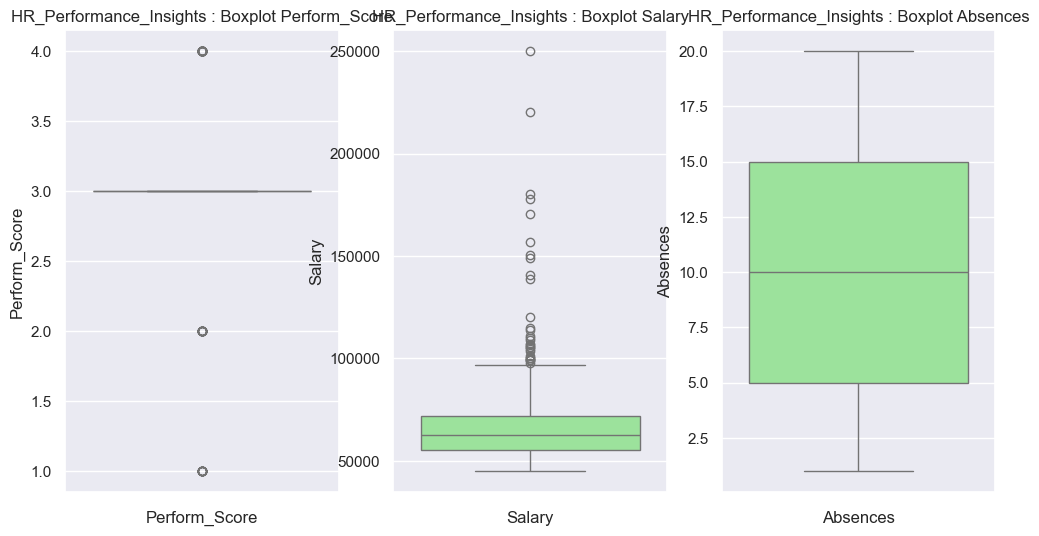

In [15]:
# 4️⃣ Visualisation des distributions
plt.figure(figsize=(15,5))
for i, col in enumerate(cols_analyse[:3]):  # Perform_Score, Salary et Absences
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True, bins=15, color='skyblue')
    plt.title(f'HR_Performance_Insights : Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')

plt.tight_layout
plt.show()

# Boxplots pour détecter les outliers
plt.figure(figsize=(12,6))
for i, col in enumerate(cols_analyse[:3]):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'HR_Performance_Insights : Boxplot {col}')
    plt.xlabel(col)
    
plt.tight_layout
plt.show()

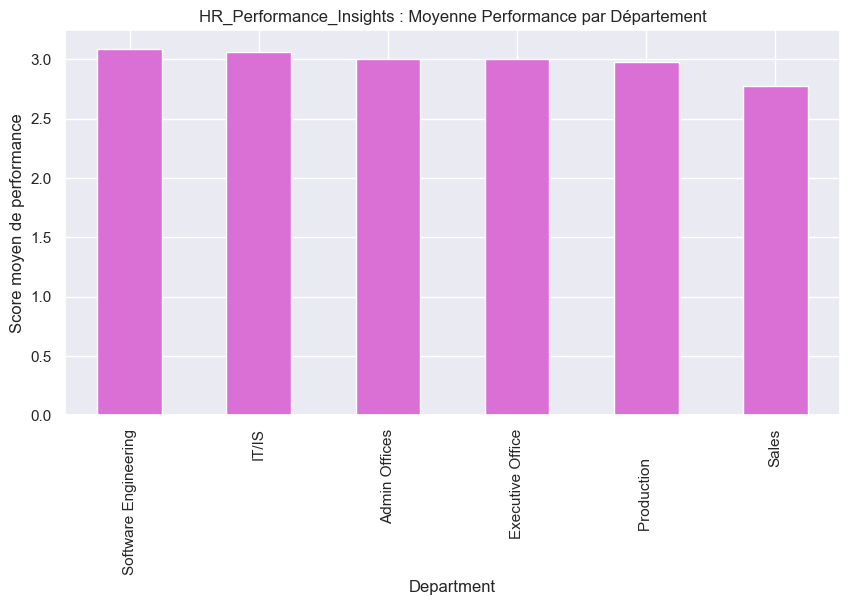

In [10]:
# 5️⃣ Diagramme en barre : moyenne Perform_Score par Département
if 'Department' in df.columns:
    mean_perf_by_dept = df.groupby('Department')['Perform_Score'].mean().sort_values(ascending=False)
    mean_perf_by_dept.plot(kind='bar', color='orchid', figsize=(10,5), title='HR_Performance_Insights : Moyenne Performance par Département')
    plt.ylabel('Score moyen de performance')
    plt.show()

In [16]:
# 6️⃣ Détection des outliers avec la règle 1.5*IQR
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers

outliers_perf = detect_outliers(df['Perform_Score'])
outliers_salary = detect_outliers(df['Salary'])
outliers_absences = detect_outliers(df['Absences'])

print(f"\nNombre d'outliers PerformanceScore : {len(outliers_perf)}")
print(outliers_perf)

print(f"\nNombre d'outliers Salary : {len(outliers_salary)}")
print(outliers_salary)

print(f"\nNombre d'outliers Absences : {len(outliers_absences)}")
print(outliers_absences)


Nombre d'outliers PerformanceScore : 68
0      4
5      4
12     4
16     4
22     4
      ..
293    4
297    2
304    4
307    1
308    4
Name: Perform_Score, Length: 68, dtype: int64

Nombre d'outliers Salary : 29
1      104437
18     110000
25     103613
26     106367
39     100031
42     110929
55     170500
66     101199
76     138888
86      99280
96     178000
97      99351
108    114800
120     99020
130     97999
131    180000
144    105700
150    250000
180    105688
190    157000
212    108987
239    120000
240    150290
243    140920
244    148999
285    100416
292    113999
299    107226
308    220450
Name: Salary, dtype: int64

Nombre d'outliers Absences : 0
Series([], Name: Absences, dtype: int64)


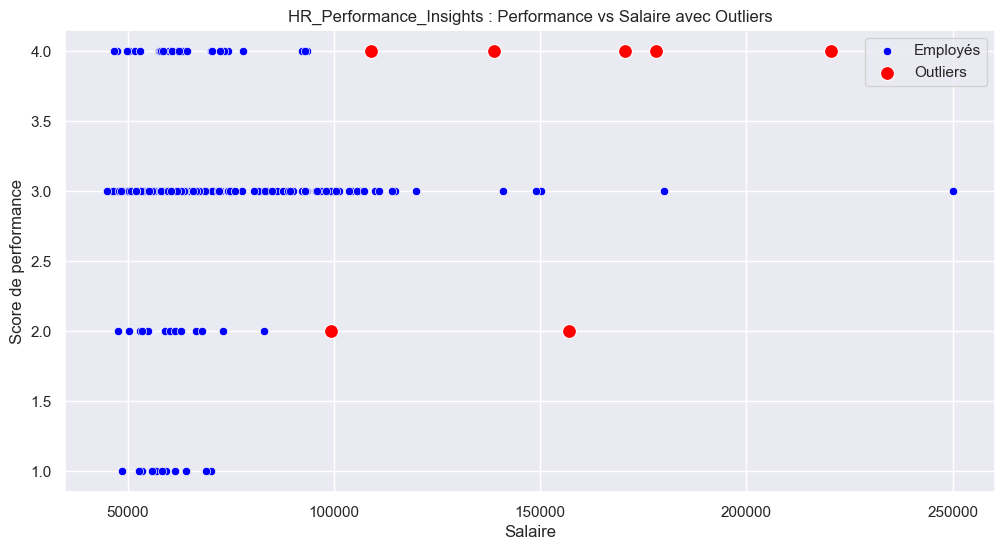

In [18]:
# 7️⃣ Scatter plot PerformanceScore vs Salary avec outliers
plt.figure(figsize=(12,6))
sns.scatterplot(x='Salary', y='Perform_Score', data=df, color='blue', label='Employés')
sns.scatterplot(x=outliers_salary, y=outliers_perf, color='red', s=100, label='Outliers')
plt.xlabel('Salaire')
plt.ylabel('Score de performance')
plt.title('HR_Performance_Insights : Performance vs Salaire avec Outliers')
plt.legend()
plt.show()


### Analyse de la corrélation entre les absences, les salaires et les perfomances

Corrélation entre Salaires et Scores de Performance : 0.12513801165277133
Corrélation entre Absences et Scores de Performance : 0.037240258112528075


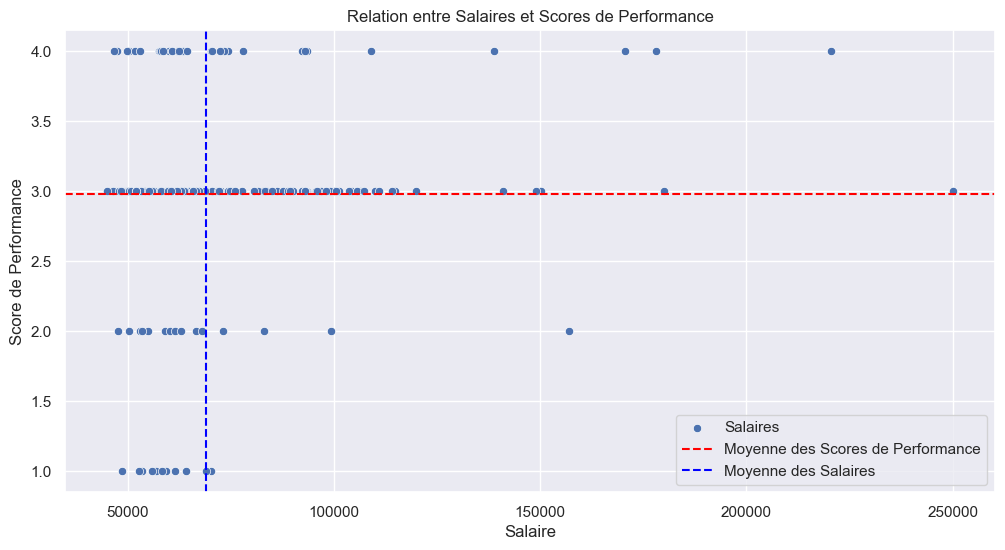

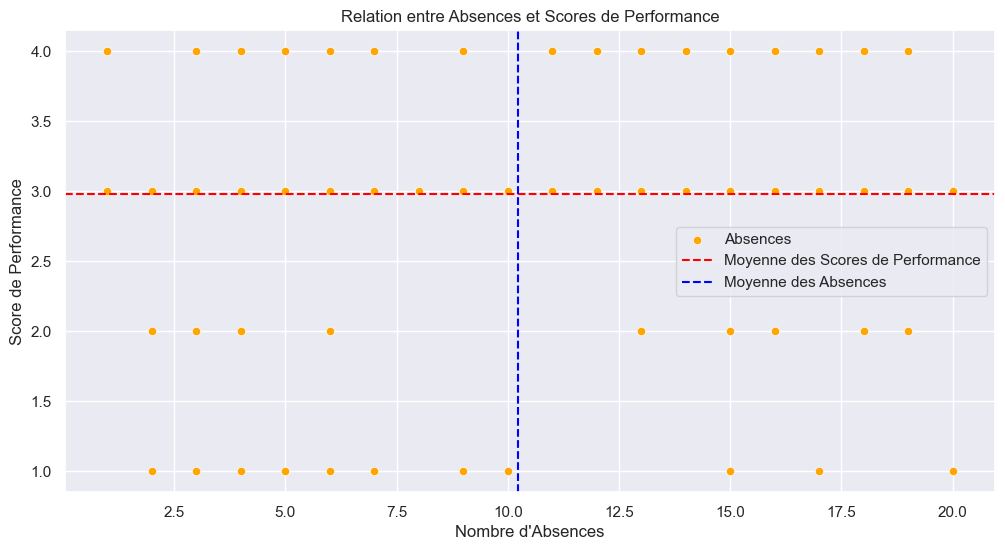

In [12]:
# Corrélations
correlation_salary = df['Salary'].corr(df['Perform_Score'])
correlation_absence = df['Absences'].corr(df['Perform_Score'])

print(f"Corrélation entre Salaires et Scores de Performance : {correlation_salary}")
print(f"Corrélation entre Absences et Scores de Performance : {correlation_absence}")

# Diagramme de dispersion
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Salary', y='Perform_Score', data=df, label='Salaires')
plt.title('Relation entre Salaires et Scores de Performance')
plt.xlabel('Salaire')
plt.ylabel('Score de Performance')
plt.axhline(y=df['Perform_Score'].mean(), color='red', linestyle='--', label='Moyenne des Scores de Performance')
plt.axvline(x=df['Salary'].mean(), color='blue', linestyle='--', label='Moyenne des Salaires')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(x='Absences', y='Perform_Score', data=df, label='Absences', color='orange')
plt.title('Relation entre Absences et Scores de Performance')
plt.xlabel('Nombre d\'Absences')
plt.ylabel('Score de Performance')
plt.axhline(y=df['Perform_Score'].mean(), color='red', linestyle='--', label='Moyenne des Scores de Performance')
plt.axvline(x=df['Absences'].mean(), color='blue', linestyle='--', label='Moyenne des Absences')
plt.legend()
plt.show()
